Pipistrellus sampling rate: 384000
Myotis sampling rate: 40000


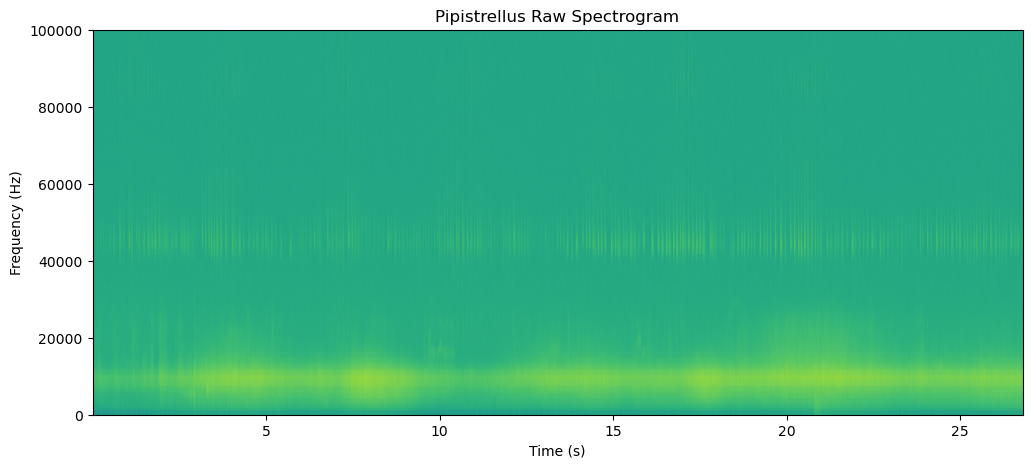

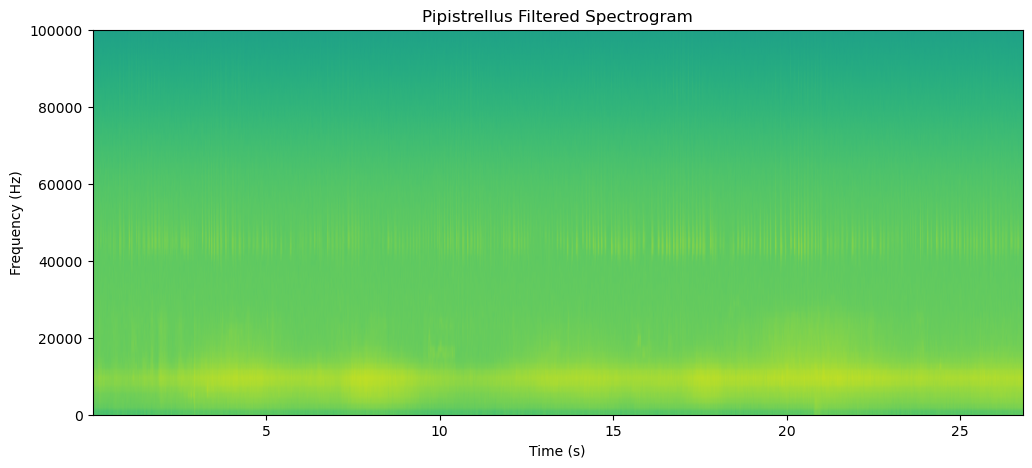

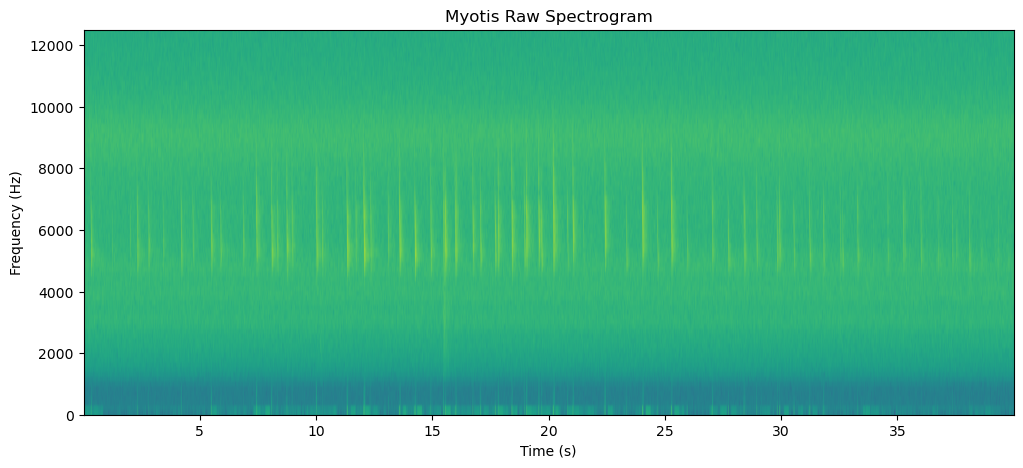

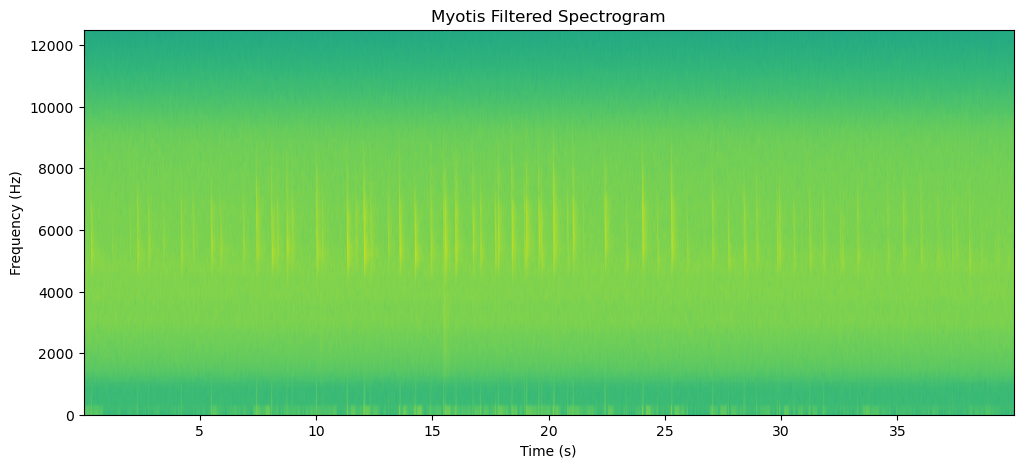

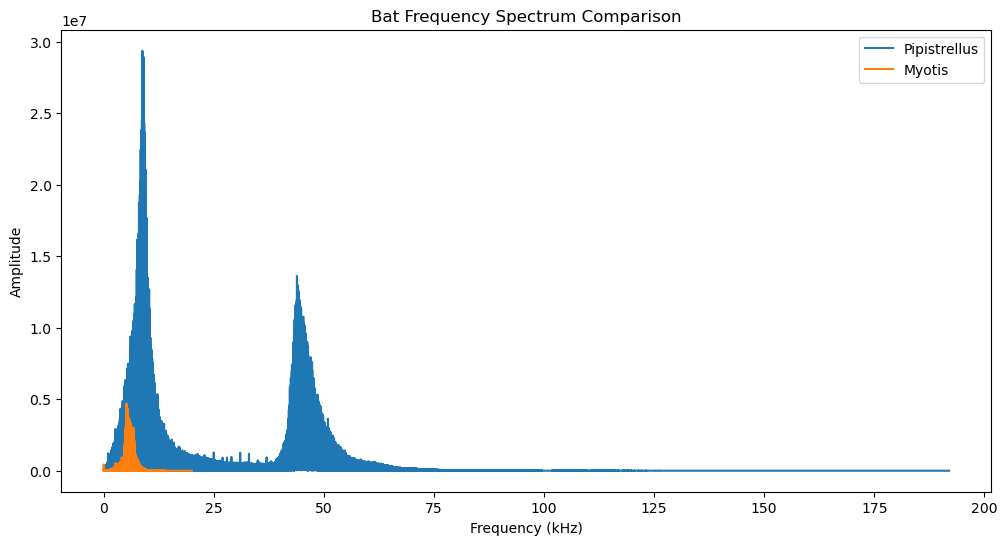

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt
from scipy.fft import fft
import warnings
warnings.filterwarnings("ignore")

# Files
pip_file = "Pipistrellus/A005200_HECGNLLRCI.WAV"
myo_file = "Myotis/A005845_AXIWDWNQRZ.WAV"


sr_pip, pip_audio = wavfile.read(pip_file)
sr_myo, myo_audio = wavfile.read(myo_file)

# convert stereo → mono if needed
if pip_audio.ndim > 1:
    pip_audio = pip_audio[:,0]

if myo_audio.ndim > 1:
    myo_audio = myo_audio[:,0]

print("Pipistrellus sampling rate:", sr_pip)
print("Myotis sampling rate:", sr_myo)

# Low Pass Filter
def lowpass_filter(signal, fs, cutoff, order=4):

    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low')
    filtered = filtfilt(b, a, signal)

    return filtered

pip_filtered = lowpass_filter(pip_audio, sr_pip, cutoff=60000)
myo_filtered = lowpass_filter(myo_audio, sr_myo, cutoff=8000)

# Pip Spectrogram
plt.figure(figsize=(12,5))

plt.specgram(pip_audio, Fs=sr_pip)
plt.ylim(0,100000)   # limit y-axis to 100 kHz
plt.title("Pipistrellus Raw Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


plt.figure(figsize=(12,5))

plt.specgram(pip_filtered, Fs=sr_pip)
plt.ylim(0,100000)   # limit y-axis to 100 kHz
plt.title("Pipistrellus Filtered Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


# Myo Spectrogram-
plt.figure(figsize=(12,5))

plt.specgram(myo_audio, Fs=sr_myo)
plt.ylim(0,12500)   # limit y-axis to 12.5 kHz
plt.title("Myotis Raw Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


plt.figure(figsize=(12,5))

plt.specgram(myo_filtered, Fs=sr_myo)
plt.ylim(0,12500)   # limit y-axis to 12.5 kHz
plt.title("Myotis Filtered Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()


def compute_fft(signal, fs):

    N = len(signal)
    spectrum = np.abs(fft(signal))
    freqs = np.fft.fftfreq(N, 1/fs)

    mask = freqs > 0
    return freqs[mask], spectrum[mask]

freq_pip, spec_pip = compute_fft(pip_filtered, sr_pip)
freq_myo, spec_myo = compute_fft(myo_filtered, sr_myo)


plt.figure(figsize=(12,6))

plt.plot(freq_pip/1000, spec_pip, label="Pipistrellus")
plt.plot(freq_myo/1000, spec_myo, label="Myotis")

plt.xlabel("Frequency (kHz)")
plt.ylabel("Amplitude")
plt.title("Bat Frequency Spectrum Comparison")

plt.legend()
plt.show()

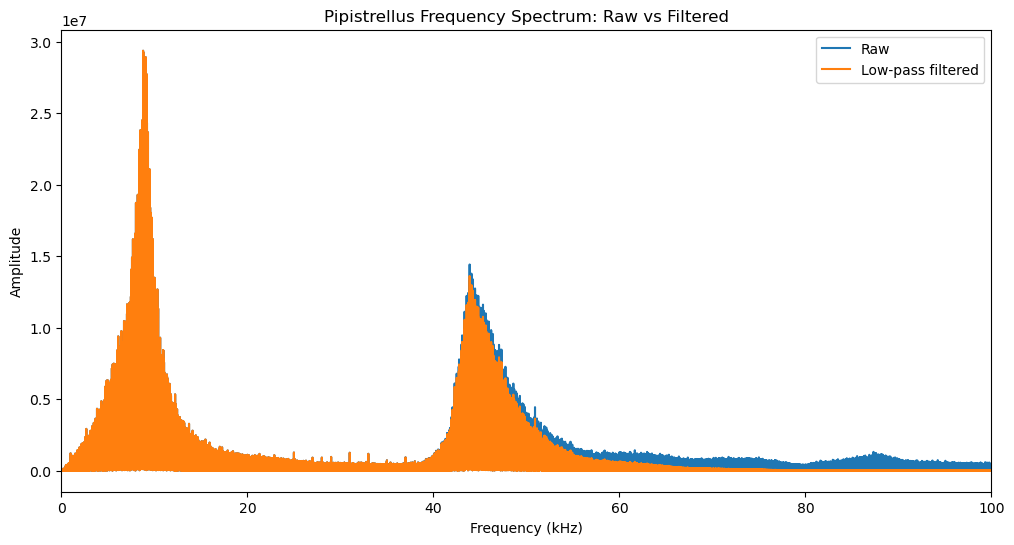

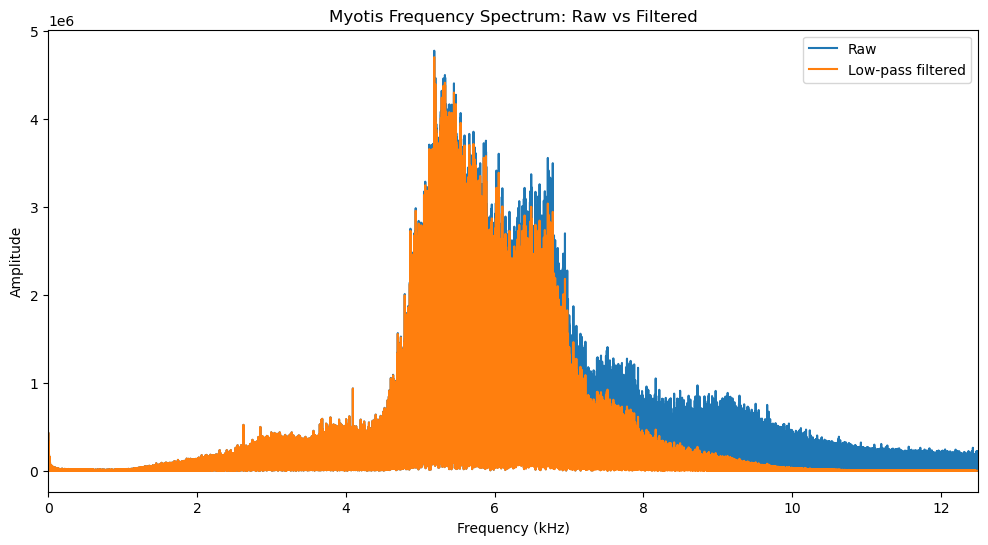

In [6]:

def compute_fft(signal, fs):

    N = len(signal)
    spectrum = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(N, 1/fs)

    mask = freqs > 0
    return freqs[mask], spectrum[mask]


freq_pip_raw, spec_pip_raw = compute_fft(pip_audio, sr_pip)
freq_pip_filt, spec_pip_filt = compute_fft(pip_filtered, sr_pip)

freq_myo_raw, spec_myo_raw = compute_fft(myo_audio, sr_myo)
freq_myo_filt, spec_myo_filt = compute_fft(myo_filtered, sr_myo)

# Pip comparison
plt.figure(figsize=(12,6))

plt.plot(freq_pip_raw/1000, spec_pip_raw, label="Raw")
plt.plot(freq_pip_filt/1000, spec_pip_filt, label="Low-pass filtered")

plt.xlim(0,100)  # show up to 100 kHz
plt.xlabel("Frequency (kHz)")
plt.ylabel("Amplitude")
plt.title("Pipistrellus Frequency Spectrum: Raw vs Filtered")

plt.legend()
plt.show()

#Myo Comparison
plt.figure(figsize=(12,6))

plt.plot(freq_myo_raw/1000, spec_myo_raw, label="Raw")
plt.plot(freq_myo_filt/1000, spec_myo_filt, label="Low-pass filtered")

plt.xlim(0,12.5)  # show up to 12.5 kHz
plt.xlabel("Frequency (kHz)")
plt.ylabel("Amplitude")
plt.title("Myotis Frequency Spectrum: Raw vs Filtered")

plt.legend()
plt.show()

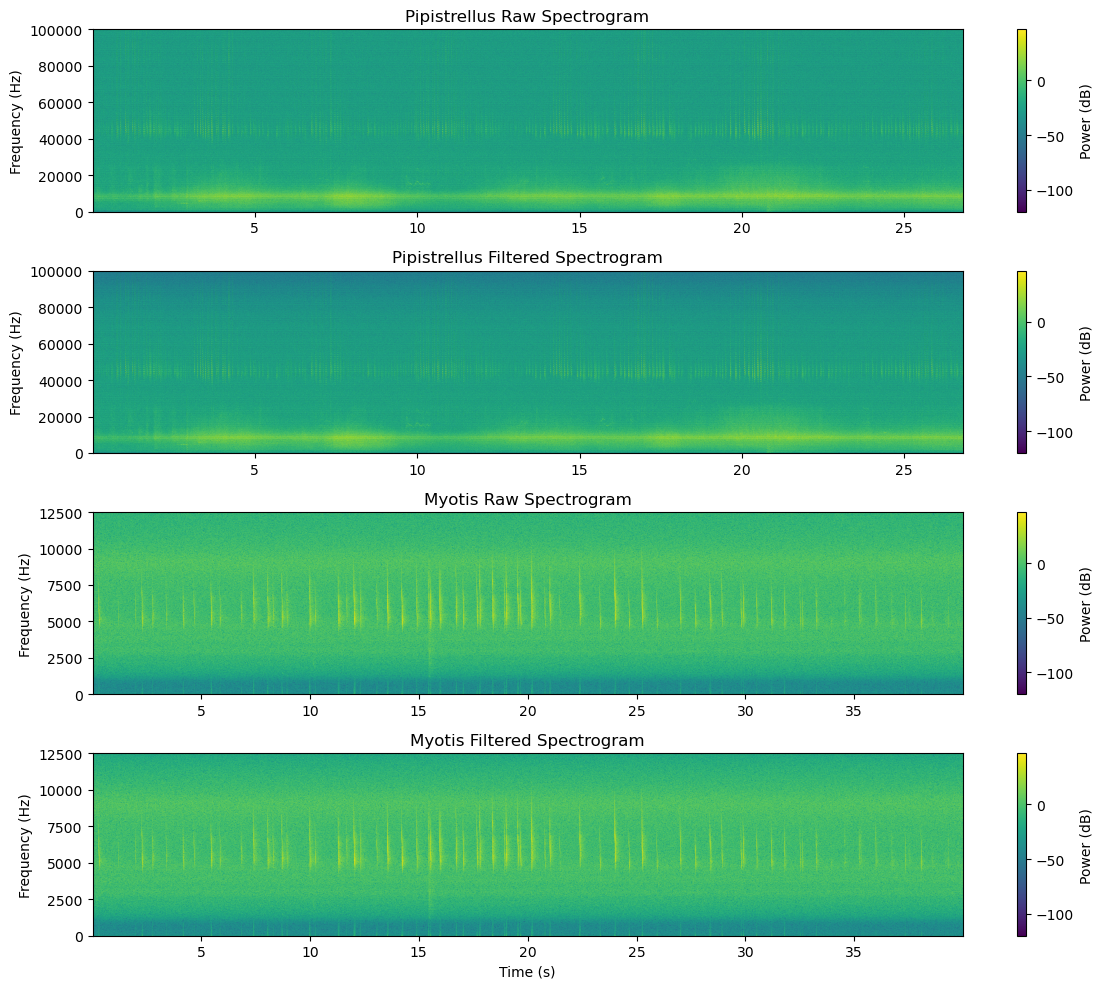

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram


def compute_spec(signal, fs):

    f, t, Sxx = spectrogram(signal, fs, nperseg=1024)

    # convert to dB
    Sxx_db = 10 * np.log10(Sxx + 1e-12)

    return f, t, Sxx_db



f_pip_raw, t_pip_raw, S_pip_raw = compute_spec(pip_audio, sr_pip)
f_pip_filt, t_pip_filt, S_pip_filt = compute_spec(pip_filtered, sr_pip)

f_myo_raw, t_myo_raw, S_myo_raw = compute_spec(myo_audio, sr_myo)
f_myo_filt, t_myo_filt, S_myo_filt = compute_spec(myo_filtered, sr_myo)


vmin = min(S_pip_raw.min(), S_pip_filt.min(), S_myo_raw.min(), S_myo_filt.min())
vmax = max(S_pip_raw.max(), S_pip_filt.max(), S_myo_raw.max(), S_myo_filt.max())


# Plots
plt.figure(figsize=(12,10))

# Pip raw
plt.subplot(4,1,1)
plt.pcolormesh(t_pip_raw, f_pip_raw, S_pip_raw, shading='gouraud', vmin=vmin, vmax=vmax)
plt.title("Pipistrellus Raw Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.ylim(0,100000)
plt.colorbar(label="Power (dB)")

# Pip filtered
plt.subplot(4,1,2)
plt.pcolormesh(t_pip_filt, f_pip_filt, S_pip_filt, shading='gouraud', vmin=vmin, vmax=vmax)
plt.title("Pipistrellus Filtered Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.ylim(0,100000)
plt.colorbar(label="Power (dB)")

# Myotis raw
plt.subplot(4,1,3)
plt.pcolormesh(t_myo_raw, f_myo_raw, S_myo_raw, shading='gouraud', vmin=vmin, vmax=vmax)
plt.title("Myotis Raw Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.ylim(0,12500)
plt.colorbar(label="Power (dB)")

# Myotis filtered
plt.subplot(4,1,4)
plt.pcolormesh(t_myo_filt, f_myo_filt, S_myo_filt, shading='gouraud', vmin=vmin, vmax=vmax)
plt.title("Myotis Filtered Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0,12500)
plt.colorbar(label="Power (dB)")

plt.tight_layout()
plt.show()